In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import os
from pymongo import MongoClient
from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")

load_dotenv("../.env")
MONGODB_URI = os.getenv("MONGODB_URI")

print("Imports done ✅")

Imports done ✅


In [2]:
client = MongoClient(MONGODB_URI)
db     = client["pearls_aqi"]
data   = list(db["aqi_engineered"].find({}, {"_id": 0}))
client.close()

df = pd.DataFrame(data)

ridge    = joblib.load("../models/ridge.pkl")
lasso    = joblib.load("../models/lasso.pkl")
gb       = joblib.load("../models/gradient_boosting.pkl")
scaler   = joblib.load("../models/scaler.pkl")
le       = joblib.load("../models/label_encoder.pkl")

feature_cols = [
    "hour", "day", "month",
    "temperature", "humidity", "wind_speed",
    "pm2_5", "pm10", "no2", "co", "o3",
    "aqi_lag_1", "aqi_lag_3", "aqi_lag_24",
    "aqi_rolling_mean_24", "aqi_change_rate",
    "time_of_day", "is_weekend", "season"
]

df["time_of_day"] = le.transform(df["time_of_day"])
df["season"]      = pd.factorize(df["season"])[0]

X        = df[feature_cols]
X_scaled = scaler.transform(X)

print(f"Data loaded: {df.shape} ✅")
print("Models loaded ✅")

Data loaded: (2160, 23) ✅
Models loaded ✅


#### SHAP for Ridge and Lasso:

In [3]:
explainer_ridge = shap.LinearExplainer(ridge, X_scaled)
shap_values_ridge = explainer_ridge.shap_values(X_scaled)

explainer_lasso = shap.LinearExplainer(lasso, X_scaled)
shap_values_lasso = explainer_lasso.shap_values(X_scaled)

print("SHAP values computed for Ridge and Lasso ✅")

SHAP values computed for Ridge and Lasso ✅


#### SHAP for Gradient Boosting:

In [4]:
explainer_gb    = shap.TreeExplainer(gb)
shap_values_gb  = explainer_gb.shap_values(X)

print("SHAP values computed for Gradient Boosting ✅")

SHAP values computed for Gradient Boosting ✅


#### Compare all 3 models:

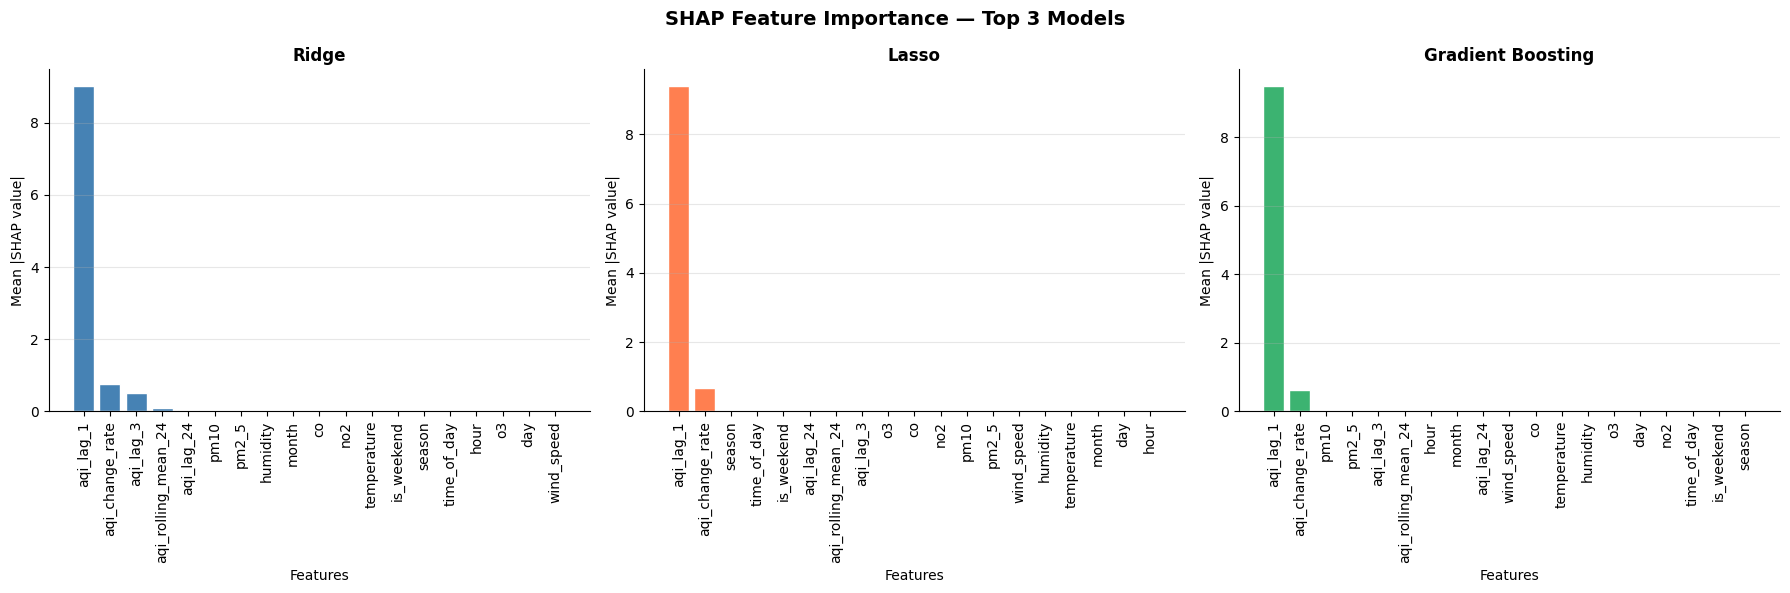

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("SHAP Feature Importance — Top 3 Models", fontsize=14, fontweight="bold")

models_data = [
    ("Ridge",             shap_values_ridge, "steelblue"),
    ("Lasso",             shap_values_lasso, "coral"),
    ("Gradient Boosting", shap_values_gb,    "mediumseagreen"),
]

for ax, (name, shap_vals, color) in zip(axes, models_data):
    importance  = np.abs(shap_vals).mean(axis=0)
    sorted_idx  = np.argsort(importance)[::-1]
    sorted_feat = [feature_cols[i] for i in sorted_idx]
    sorted_imp  = importance[sorted_idx]

    ax.bar(sorted_feat, sorted_imp, color=color, edgecolor="white")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Features")
    ax.set_ylabel("Mean |SHAP value|")
    ax.tick_params(axis="x", rotation=90)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Top 5 features:

In [6]:
print("Top 5 Most Important Features\n")

for name, shap_vals, _ in models_data:
    importance = np.abs(shap_vals).mean(axis=0)
    sorted_idx = np.argsort(importance)[::-1][:5]
    print(f"--- {name} ---")
    for rank, idx in enumerate(sorted_idx, 1):
        print(f"  {rank}. {feature_cols[idx]:25s} → {importance[idx]:.4f}")
    print()

Top 5 Most Important Features

--- Ridge ---
  1. aqi_lag_1                 → 9.0352
  2. aqi_change_rate           → 0.7541
  3. aqi_lag_3                 → 0.5048
  4. aqi_rolling_mean_24       → 0.0819
  5. aqi_lag_24                → 0.0218

--- Lasso ---
  1. aqi_lag_1                 → 9.4080
  2. aqi_change_rate           → 0.6578
  3. season                    → 0.0000
  4. time_of_day               → 0.0000
  5. is_weekend                → 0.0000

--- Gradient Boosting ---
  1. aqi_lag_1                 → 9.5098
  2. aqi_change_rate           → 0.6315
  3. pm10                      → 0.0210
  4. pm2_5                     → 0.0142
  5. aqi_lag_3                 → 0.0114

